# Checkpoint 4

## Aplicación 1: Optimización bajo restricción de riesgo
### Objetivo
Diseñar el portafolio de mayor rendimiento esperado sujeto a un límite de riesgo.

### Instrucciones
1. Generen al menos 30 combinaciones de pesos (que sumen 1).

2. Simulen entre 5,000 y 10,000 rendimientos para cada combinación.

3. Calculen para cada portafolio:
    - Rendimiento promedio.
    - Desviación estándar.
    - VaR 95%.

4. Impongan la restricción:
    - VaR 95% ≥ –5%.

5. Identifiquen el portafolio con mayor rendimiento esperado que cumpla la restricción.

6. Construyan:
- Scatter plot riesgo (desviación o VaR) vs rendimiento esperado.
- Histograma del portafolio elegido.

7. Respondan:
- ¿Cuántos portafolios cumplen la restricción?
- ¿Cuánto rendimiento se sacrifica por controlar riesgo?

C:\Users\j_ale\AppData\Local\Temp\ipykernel_10616\3083887545.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=start, end=end, progress=False)["Close"]


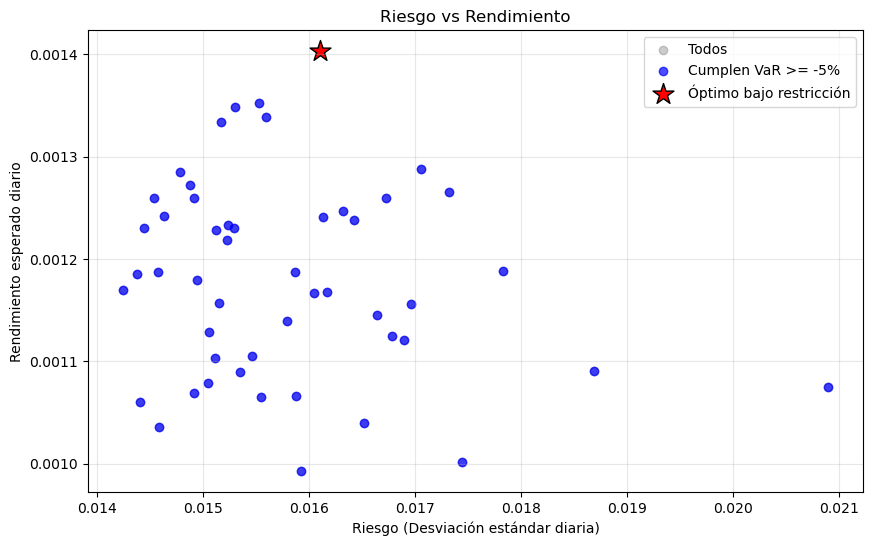

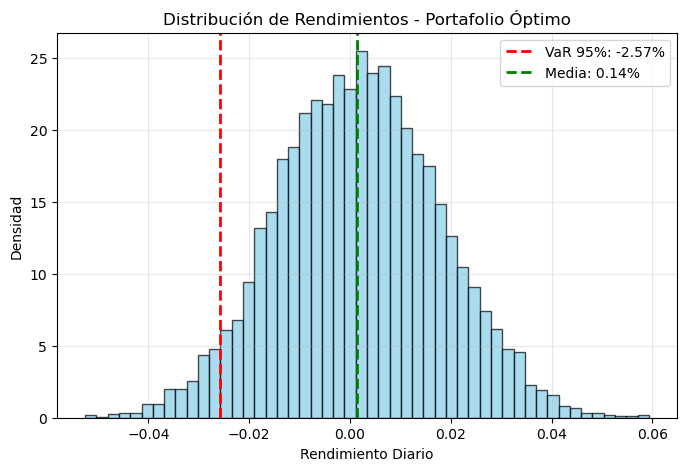


 RESULTADOS DE LA OPTIMIZACIÓN
Total de portafolios evaluados: 50
Portafolios que cumplen la restricción: 50

Rendimiento máximo SIN restricción: 0.1403%
Rendimiento máximo CON restricción: 0.1403%
Sacrificio de rendimiento: 0.0000%

Pesos del portafolio elegido:
{'JPM': 0.0828, 'META': 0.6933, 'TSM': 0.0326, 'LLY': 0.1914}


In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt

tickers = ["JPM", "META", "TSM", "LLY"]
start = "2018-01-01"
end = "2026-02-24"

prices = yf.download(tickers, start=start, end=end, progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

# 2. Parámetros simulación
n_portfolios = 50          
n_sim = 7500              
confidence = 0.95
var_limit = -0.05          

results = []
np.random.seed(42)        

# =========================
# 3. Simulación Monte Carlo
# =========================
for _ in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    port_mean = np.dot(weights, mean_returns)
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    simulated_returns = np.random.normal(port_mean, port_std, n_sim)
    VaR_95 = np.percentile(simulated_returns, 5)

    results.append({
        "Weights": weights,
        "Mean": port_mean,
        "Std": port_std,
        "VaR_95": VaR_95
    })

results_df = pd.DataFrame(results)

feasible = results_df[results_df["VaR_95"] >= var_limit]
optimal_port = feasible.loc[feasible["Mean"].idxmax()]
max_return_port = results_df.loc[results_df["Mean"].idxmax()]

plt.figure(figsize=(10,6))
plt.scatter(results_df["Std"], results_df["Mean"], alpha=0.4, color="gray", label="Todos")
plt.scatter(feasible["Std"], feasible["Mean"], alpha=0.7, color="blue", label="Cumplen VaR >= -5%")
plt.scatter(optimal_port["Std"], optimal_port["Mean"], color="red", s=250, marker='*', edgecolor='black', label="Óptimo bajo restricción")

plt.xlabel("Riesgo (Desviación estándar diaria)")
plt.ylabel("Rendimiento esperado diario")
plt.title("Riesgo vs Rendimiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Gráfico 2: Histograma ---
sim_opt = np.random.normal(optimal_port["Mean"], optimal_port["Std"], n_sim)

plt.figure(figsize=(8,5))
plt.hist(sim_opt, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(optimal_port["VaR_95"], color='red', linestyle="--", linewidth=2, label=f'VaR 95%: {optimal_port["VaR_95"]:.2%}')
plt.axvline(optimal_port["Mean"], color='green', linestyle="--", linewidth=2, label=f'Media: {optimal_port["Mean"]:.2%}')

plt.title("Distribución de Rendimientos - Portafolio Óptimo")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Resultados en Consola ---
print("\n" + "=" * 45)
print(" RESULTADOS DE LA OPTIMIZACIÓN")
print("=" * 45)
print(f"Total de portafolios evaluados: {n_portfolios}")
print(f"Portafolios que cumplen la restricción: {len(feasible)}")
print(f"\nRendimiento máximo SIN restricción: {max_return_port['Mean']:.4%}")
print(f"Rendimiento máximo CON restricción: {optimal_port['Mean']:.4%}")
print(f"Sacrificio de rendimiento: {max_return_port['Mean'] - optimal_port['Mean']:.4%}")

# Mostrar los pesos asignados a cada activo
pesos_dict = {tickers[i]: round(optimal_port['Weights'][i], 4) for i in range(len(tickers))}
print(f"\nPesos del portafolio elegido:\n{pesos_dict}")

7. Respondan:
- ¿Cuántos portafolios cumplen la restricción? Los 50
- ¿Cuánto rendimiento se sacrifica por controlar riesgo? 0 

## Aplicación 2: Escenarios macroeconómicos
### Objetivo
Explorar cómo cambia el comportamiento del portafolio bajo distintos contextos económicos.

### Instrucciones
1. Definan tres escenarios:
- Base: usar los rendimientos originales.
- Alcista: aumentar la media en +0.001.
- Bajista: disminuir la media en –0.001.

2. Simulen al menos 10,000 trayectorias para cada escenario.

3. Calculen para cada escenario:
- Rendimiento promedio.
- Desviación estándar.
- Probabilidad de pérdida.
- VaR 95%.

4. Construyan:
- Histogramas comparativos de las distribuciones.
- Gráfico comparativo de medias y desviaciones estándar.

5. Analicen:
- ¿En qué escenario la probabilidad de pérdida es mayor?
- ¿Cuál presenta mayor dispersión de resultados?
- ¿Cambian de manera relevante las métricas de riesgo extremo?

          Rendimiento Promedio Desviación Estándar Prob. de Pérdida VaR 95%
Escenario                                                                  
Base                     0.14%               1.62%           46.46%  -2.53%
Alcista                  0.26%               1.61%           43.60%  -2.35%
Bajista                  0.02%               1.60%           49.31%  -2.56%


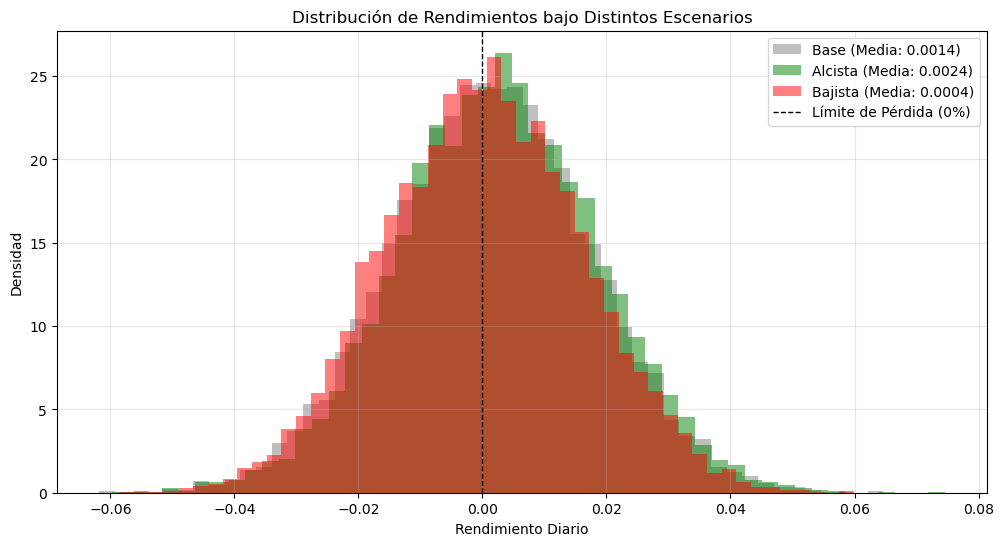

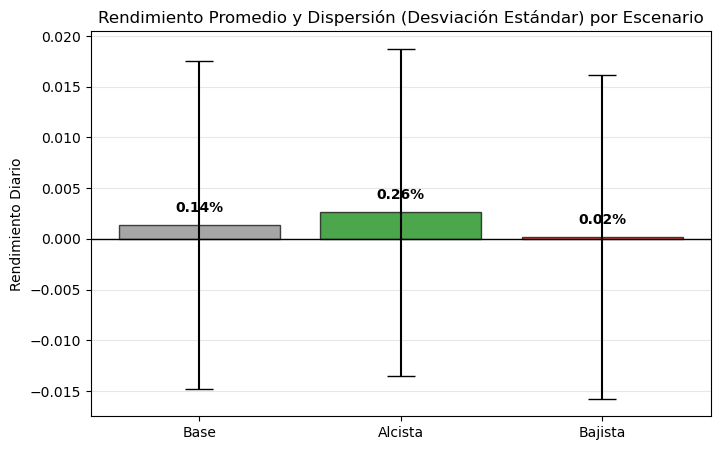

In [16]:
base_mean = optimal_port["Mean"]
base_std = optimal_port["Std"]
n_sim_macro = 10000

scenarios = {
    "Base": base_mean,
    "Alcista": base_mean + 0.001,
    "Bajista": base_mean - 0.001
}

simulations = {}
metrics_list = []

np.random.seed(42)

for name, mean_val in scenarios.items():
    sim_returns = np.random.normal(mean_val, base_std, n_sim_macro)
    simulations[name] = sim_returns
    
    promedio = np.mean(sim_returns)
    desviacion = np.std(sim_returns)
    prob_perdida = np.mean(sim_returns < 0)  # Proporción de simulaciones menores a 0
    var_95 = np.percentile(sim_returns, 5)
    
    metrics_list.append({
        "Escenario": name,
        "Rendimiento Promedio": promedio,
        "Desviación Estándar": desviacion,
        "Prob. de Pérdida": prob_perdida,
        "VaR 95%": var_95
    })

df_macro = pd.DataFrame(metrics_list).set_index("Escenario")

df_macro_style = df_macro.copy()
for col in df_macro_style.columns:
    df_macro_style[col] = df_macro_style[col].apply(lambda x: f"{x:.2%}")
print(df_macro_style)


plt.figure(figsize=(12, 6))
colores = {"Base": "gray", "Alcista": "green", "Bajista": "red"}

for name, sim in simulations.items():
    plt.hist(sim, bins=50, alpha=0.5, label=f"{name} (Media: {scenarios[name]:.4f})", color=colores[name], density=True)

plt.title("Distribución de Rendimientos bajo Distintos Escenarios")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Densidad")
plt.axvline(0, color='black', linestyle='--', linewidth=1, label="Límite de Pérdida (0%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
x_pos = np.arange(len(df_macro.index))
medias = df_macro["Rendimiento Promedio"]
desviaciones = df_macro["Desviación Estándar"]

bars = plt.bar(x_pos, medias, yerr=desviaciones, capsize=10, color=['gray', 'green', 'red'], alpha=0.7, edgecolor='black')

plt.xticks(x_pos, df_macro.index)
plt.axhline(0, color='black', linewidth=1)
plt.title("Rendimiento Promedio y Dispersión (Desviación Estándar) por Escenario")
plt.ylabel("Rendimiento Diario")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (0.001 if yval > 0 else -0.002), 
             f"{yval:.2%}", ha='center', va='bottom' if yval > 0 else 'top', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

- ¿En qué escenario la probabilidad de pérdida es mayor? Bajista
- ¿Cuál presenta mayor dispersión de resultados? Parece ser practicamente la misma en todas, todas estan en un rango similar.
- ¿Cambian de manera relevante las métricas de riesgo extremo? No hay mucho cambio entre el base y bajista, pero el alcista parece si cambiar bastante. 